In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.shape

(100, 4)

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
df = df.iloc[:, 1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0



# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [6]:
import matplotlib.pyplot as plt

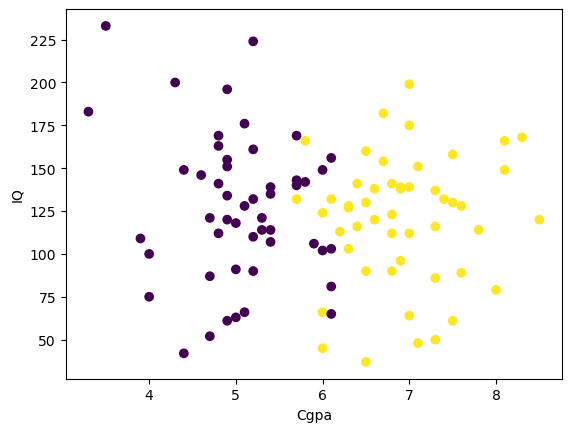

In [12]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
plt.xlabel("Cgpa")
plt.ylabel("IQ")
plt.show()


In [13]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [17]:
x = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [20]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

In [21]:
from sklearn.model_selection  import train_test_split


In [24]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [26]:
X_train

,cgpa,iq
84,5.7,169.0
89,4.9,151.0
13,6.4,116.0
2,5.3,121.0
97,6.7,182.0
86,5.1,128.0
98,6.3,103.0
7,5.0,63.0
87,5.7,132.0
90,7.3,86.0


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

In [29]:
X_train = scaler.fit_transform(X_train)

In [30]:
X_train

array([[-1.03160417,  1.13162631],
       [-1.03160417,  0.98269182],
       [ 0.07877014, -0.50665306],
       [-0.51912372,  0.28766421],
       [-0.68995054, -0.82934446],
       [-0.94619076,  0.26284179],
       [-0.00664327, -1.94635312],
       [ 0.24959696,  0.08908489],
       [-1.71491144, -1.20168068],
       [-0.86077735, -0.13431684],
       [ 0.07877014, -1.05274619],
       [ 0.67666401, -0.01020477],
       [-0.68995054, -0.33289616],
       [-0.00664327, -0.53147548],
       [ 1.78703832,  1.05715906],
       [-1.45867122,  1.90112116],
       [-1.11701758, -1.77259621],
       [ 0.33501037,  0.43659869],
       [ 1.10373105, -1.82224104],
       [-0.17747008,  1.05715906],
       [ 0.84749082,  0.38695386],
       [ 1.70162491, -1.10239102],
       [ 1.35997128,  0.1139073 ],
       [ 0.07877014, -1.44990482],
       [ 0.24959696,  0.1139073 ],
       [-0.51912372, -0.2336065 ],
       [ 0.42042378, -0.82934446],
       [-0.60453713, -0.2336065 ],
       [ 2.12869196,

In [31]:
X_test = scaler.transform(X_test)

In [32]:
X_test

array([[-0.26288349,  1.13162631],
       [-0.94619076,  0.68482284],
       [ 0.33501037, -0.18396167],
       [-0.60453713, -0.0598496 ],
       [ 0.5912506 ,  1.4543177 ],
       [-0.77536395,  0.1139073 ],
       [ 0.24959696, -0.50665306],
       [-0.86077735, -1.49954965],
       [-0.26288349,  0.21319696],
       [ 1.10373105, -0.92863411]])

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
clf = LogisticRegression()

In [38]:
# model traning
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
# 5. Evaluate the model/model selection
clf.predict(X_test)

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 1])

In [41]:
y_pred = clf.predict(X_test)

In [40]:
y_test

84    0
89    0
13    1
2     0
97    1
86    0
98    1
7     0
87    1
90    1
Name: placement, dtype: int64

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
accuracy_score(y_test, y_pred)

0.9

In [46]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 6.3 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.3 MB 7.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.3 MB 8.4 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 8.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 7.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 6.6 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 5.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 5.4 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 5.2 MB/s eta 0:00:01
   ------------------------

In [47]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

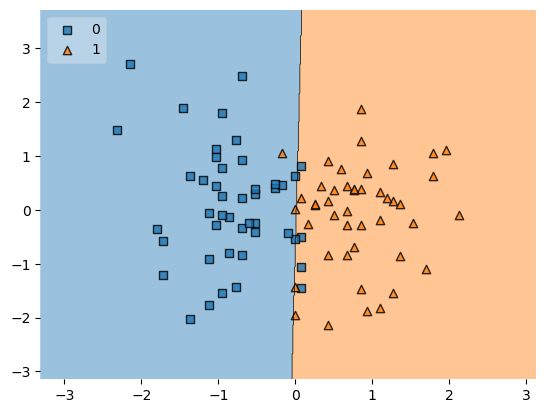

In [48]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [49]:
import pickle

In [50]:
pickle.dump(clf,open('model.pkl','wb'))